In [ ]:
from huggingface_hub import snapshot_download
print(snapshot_download("riffusion/riffusion-model-v1", local_files_only=True))

In [ ]:
from huggingface_hub import snapshot_download

repo_id = "riffusion/riffusion-model-v1"

path = snapshot_download(repo_id)
print("Riffusion model ready at:", path)

In [1]:
!uv run src/dataset.py

Audio processing utilities loaded.
Dataset length: 800
Sample keys: ['image', 'tensor', 'spectrogram', 'timbre', 'filename']
Sample image size: (512, 512)
Sample spectrogram shape: (512, 512)
Sample timbre: piano
Sample filename: spectrogram_16_slice_0_piano.npy
Sample tensor shape: torch.Size([3, 512, 512])


In [2]:
!accelerate config default

accelerate configuration saved at /home/vtqn/.cache/huggingface/accelerate/default_config.yaml


In [1]:
# smoke test

!accelerate launch src/train.py \
  --pretrained_model_name_or_path riffusion/riffusion-model-v1 \
  --spectrograms_dir data/spectrogram \
  --timbre flute \
  --train_subset train \
  --validation_subset validation \
  --output_dir outputs/lora_flute \
  --train_batch_size 1 \
  --gradient_accumulation_steps 1 \
  --max_train_steps 10 \
  --max_train_samples 5 \
  --rank 4 \
  --learning_rate 1e-4 \
  --mixed_precision fp16 \
  --gradient_checkpointing \
  --save_steps 5 \
  --validation_steps 5 \
  --validation_max_batches 8 \
  --max_validation_samples 2 \
  --checkpoint_limit 3 \
  --dataloader_num_workers 2 \
  --verify_files

Audio processing utilities loaded.
Loading weights: 100%|█████████████████████| 196/196 [00:00<00:00, 13794.74it/s]
/home/vtqn/projects/project2/.venv/lib/python3.12/site-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
An error occurred while trying to fetch riffusion/riffusion-model-v1: riffusion/riffusion-model-v1 does not appear to have a file named diffusion_pytorch_model.safetensors.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
An error occurred while trying to fetch riffusion/riffusion-model-v1: riffusion/riffusion-model-v1 does not appear to have a file named diffusion_pytorch_model.safetensors.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
Training: 100%|██████████| 10/10 [04:46<00:00, 28.61s/it, loss=nan, lr=1.0

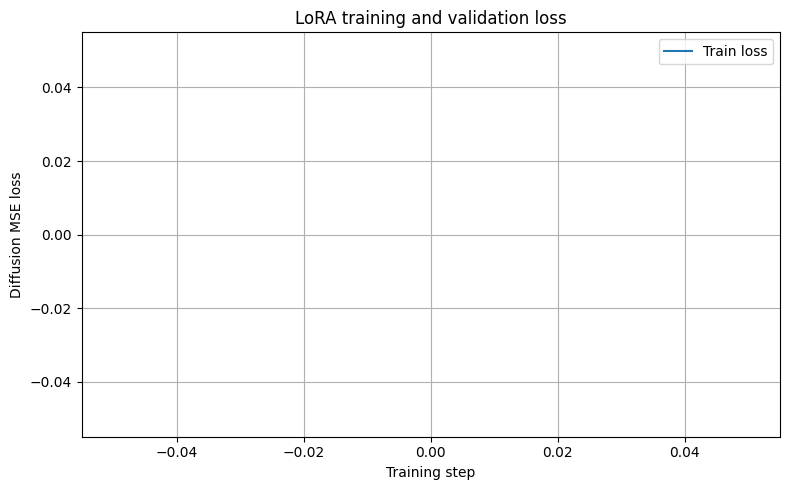

Saved plot to: outputs/lora_flute/loss_curve.png


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

output_dir = "outputs/lora_flute"  # change to outputs/lora_flute

metrics_path = f"{output_dir}/metrics.csv"
df = pd.read_csv(metrics_path)

train_df = df[df["train_loss"].notna()]
val_df = df[df["val_loss"].notna()]

plt.figure(figsize=(8, 5))
plt.plot(train_df["step"], train_df["train_loss"], label="Train loss")

if len(val_df) > 0:
    plt.plot(val_df["step"], val_df["val_loss"], marker="o", label="Validation loss")

plt.xlabel("Training step")
plt.ylabel("Diffusion MSE loss")
plt.title("LoRA training and validation loss")
plt.legend()
plt.grid(True)
plt.tight_layout()

save_path = f"{output_dir}/loss_curve.png"
plt.savefig(save_path, dpi=200)
plt.show()

print("Saved plot to:", save_path)

In [ ]:
!accelerate launch train.py \
  --pretrained_model_name_or_path riffusion/riffusion-model-v1 \
  --spectrograms_dir data/spectrogram \
  --timbre flute \
  --output_dir outputs/test_lora_flute \
  --train_batch_size 1 \
  --gradient_accumulation_steps 1 \
  --max_train_steps 5 \
  --max_train_samples 8 \
  --rank 4 \
  --learning_rate 1e-4 \
  --mixed_precision fp16 \
  --gradient_checkpointing \
  --save_steps 5 \
  --validation_steps 0 \
  --dataloader_num_workers 0